# EDA — Air Quality MLOps

## Objetivo

Realizar un análisis exploratorio técnicamente relevante sobre los datos preparados por el pipeline de Data Cleaning.

El EDA se utilizará para tomar decisiones sobre:
- tratamiento de valores faltantes;
- comportamiento temporal de las variables;
- valores extremos;
- estacionalidad;
- autocorrelación;
- relaciones entre variables;
- selección de la variable ambiental objetivo;
- futuras variables para Feature Engineering;
- estrategia de entrenamiento y evaluación del sistema de forecasting.
Cada análisis deberá responder:

**¿Qué decisión de limpieza, modelado o ingeniería de variables cambia como consecuencia de este resultado?**

La variable objetivo para forecasting no se seleccionará previamente. Su elección será justificada con los resultados obtenidos durante este EDA.

In [13]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.cleaning.clean import clean_data
df = clean_data()
df.head()

Data Cleaning completado correctamente.
Filas originales: 9471
Filas después de limpieza: 9357
Filas eliminadas: 114
Columnas: 16


,Date,Time,CO_GT,PT08_S1_CO,NMHC_GT,C6H6_GT,PT08_S2_NMHC,NOx_GT,PT08_S3_NOx,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,RH,AH,timestamp
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00


In [3]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nRango temporal:")
print("Inicio:", df["timestamp"].min())
print("Fin:", df["timestamp"].max())

Dimensiones: (9357, 16)

Tipos de datos:
Date                       str
Time                       str
CO_GT                  float64
PT08_S1_CO             float64
NMHC_GT                float64
C6H6_GT                float64
PT08_S2_NMHC           float64
NOx_GT                 float64
PT08_S3_NOx            float64
NO2_GT                 float64
PT08_S4_NO2            float64
PT08_S5_O3             float64
T                      float64
RH                     float64
AH                     float64
timestamp       datetime64[us]
dtype: object

Rango temporal:
Inicio: 2004-03-10 18:00:00
Fin: 2005-04-04 14:00:00


### 1. Estructura y cobertura temporal

Después de aplicar el pipeline reutilizable de Data Cleaning, el conjunto de datos contiene **9,357 registros y 16 columnas**.
Las 13 variables ambientales y de sensores se encuentran en formato numérico, mientras que timestamp se encuentra en formato temporal.

El período disponible comprende:
- **Inicio:** 10 de marzo de 2004, 18:00.
- **Fin:** 4 de abril de 2005, 14:00.
Esto proporciona aproximadamente un año de observaciones horarias, suficiente para investigar patrones intradía, diarios y semanales.

**Decisión:** se utilizará timestamp como referencia temporal durante el EDA. Las divisiones posteriores de entrenamiento, validación y prueba deberán respetar el orden cronológico y no realizarse aleatoriamente.

In [4]:
missing = df.isna().sum()
missing_report = (
    missing.to_frame("faltantes")
    .assign(
        porcentaje=lambda x: (x["faltantes"] / len(df) * 100).round(2),
        cobertura=lambda x: (100 - x["porcentaje"]).round(2),
    )
)
missing_report

,faltantes,porcentaje,cobertura
Date,0,0.00,100.00
Time,0,0.00,100.00
CO_GT,1683,17.99,82.01
PT08_S1_CO,366,3.91,96.09
NMHC_GT,8443,90.23,9.77
C6H6_GT,366,3.91,96.09
PT08_S2_NMHC,366,3.91,96.09
NOx_GT,1639,17.52,82.48
PT08_S3_NOx,366,3.91,96.09
NO2_GT,1642,17.55,82.45


### 2. Cobertura y valores faltantes

El análisis de cobertura muestra diferencias importantes entre las variables.
La mayoría de los sensores y variables meteorológicas presentan una cobertura aproximada del **96.09 %**, mientras que los contaminantes medidos directamente presentan menor disponibilidad:
- CO_GT: **82.01 %**
- NOx_GT: **82.48 %**
- NO2_GT: **82.45 %**
- NMHC_GT: **9.77 %**

NMHC_GT destaca especialmente porque aproximadamente el **90.23 % de sus observaciones están ausentes**.
Los valores faltantes no se eliminarán ni imputarán de forma global en este momento.
**Decisión:** NMHC_GT no se considerará inicialmente como una candidata fuerte para la variable objetivo debido a su cobertura extremadamente baja. CO_GT, NOx_GT y NO2_GT permanecen como posibles candidatas, pero su menor cobertura deberá considerarse al compararlas con variables de mayor disponibilidad. La estrategia definitiva de tratamiento de valores faltantes se decidirá después de analizar su estructura temporal y antes del entrenamiento.

In [5]:
numeric_cols = [
    "CO_GT",
    "PT08_S1_CO",
    "NMHC_GT",
    "C6H6_GT",
    "PT08_S2_NMHC",
    "NOx_GT",
    "PT08_S3_NOx",
    "NO2_GT",
    "PT08_S4_NO2",
    "PT08_S5_O3",
    "T",
    "RH",
    "AH",
]

df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
CO_GT,7674.0,2.15,1.45,0.10,1.10,1.8,2.90,11.90
PT08_S1_CO,8991.0,1099.83,217.08,647.00,937.00,1063.0,1231.00,2040.00
NMHC_GT,914.0,218.81,204.46,7.00,67.00,150.0,297.00,1189.00
C6H6_GT,8991.0,10.08,7.45,0.10,4.40,8.2,14.00,63.70
PT08_S2_NMHC,8991.0,939.15,266.83,383.00,734.50,909.0,1116.00,2214.00
NOx_GT,7718.0,246.90,212.98,2.00,98.00,180.0,326.00,1479.00
PT08_S3_NOx,8991.0,835.49,256.82,322.00,658.00,806.0,969.50,2683.00
NO2_GT,7715.0,113.09,48.37,2.00,78.00,109.0,142.00,340.00
PT08_S4_NO2,8991.0,1456.26,346.21,551.00,1227.00,1463.0,1674.00,2775.00
PT08_S5_O3,8991.0,1022.91,398.48,221.00,731.50,963.0,1273.50,2523.00


In [6]:
skewness = (
    df[numeric_cols]
    .skew()
    .sort_values(ascending=False)
    .to_frame("skewness")
)
skewness.round(3)

,skewness
NOx_GT,1.716
NMHC_GT,1.557
CO_GT,1.370
C6H6_GT,1.362
PT08_S3_NOx,1.102
PT08_S1_CO,0.756
PT08_S5_O3,0.628
NO2_GT,0.622
PT08_S2_NMHC,0.562
T,0.309


### 3. Distribución y asimetría de las variables

Las variables presentan escalas y distribuciones diferentes.
Los contaminantes con mayor asimetría positiva son:

- NOx_GT: **1.716**
- NMHC_GT: **1.557**
- CO_GT: **1.370**
- C6H6_GT: **1.362**

Esto indica que la mayor parte de las observaciones se concentra en valores relativamente bajos o medios, pero existen episodios con concentraciones considerablemente superiores.

Las variables meteorológicas presentan distribuciones más simétricas, especialmente RH, cuya skewness es aproximadamente **-0.038**.

**Decisión:** los valores extremos no serán eliminados automáticamente durante la limpieza. En un problema de calidad del aire, los picos pueden representar episodios reales de contaminación y contener información importante para el forecasting. Se analizará posteriormente su comportamiento temporal antes de decidir si requieren transformación, tratamiento robusto o conservación sin modificaciones.

In [9]:
outlier_report = []
for col in numeric_cols:
    serie = df[col].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = (
        (serie < limite_inferior) |
        (serie > limite_superior)
    ).sum()

    outlier_report.append({
        "variable": col,
        "outliers_IQR": outliers,
        "porcentaje": round(outliers / len(serie) * 100, 2)
    })

outlier_report = pd.DataFrame(outlier_report)
outlier_report

,variable,outliers_IQR,porcentaje
0,CO_GT,215,2.80
1,PT08_S1_CO,118,1.31
2,NMHC_GT,55,6.02
3,C6H6_GT,228,2.54
4,PT08_S2_NMHC,65,0.72
5,NOx_GT,435,5.64
6,PT08_S3_NOx,241,2.68
7,NO2_GT,107,1.39
8,PT08_S4_NO2,97,1.08
9,PT08_S5_O3,93,1.03


### 4. Análisis de valores extremos mediante IQR

Se utilizó el rango intercuartílico (IQR) como método exploratorio para identificar observaciones alejadas de la distribución central de cada variable.

Los mayores porcentajes se observaron en:

- NMHC_GT: **6.02 %**
- NOx_GT: **5.64 %**
- CO_GT: **2.80 %**
- PT08_S3_NOx: **2.68 %**
- C6H6_GT: **2.54 %**

Por el contrario, las variables meteorológicas presentan pocos valores extremos según IQR:

- T: **0.03 %**
- RH: **0.00 %**
- AH: **0.02 %**

La detección mediante IQR no implica que estas observaciones sean errores. En las variables de contaminación, los valores elevados pueden corresponder a episodios reales de alta concentración.

**Decisión:** no se eliminarán automáticamente los outliers identificados mediante IQR. Antes de aplicar cualquier tratamiento se analizará su comportamiento temporal y su relación con otras variables. Esto evita eliminar episodios de contaminación potencialmente importantes para el objetivo de forecasting.

In [10]:
correlation_matrix = df[numeric_cols].corr()
correlation_matrix.round(2)

,CO_GT,PT08_S1_CO,NMHC_GT,C6H6_GT,PT08_S2_NMHC,NOx_GT,PT08_S3_NOx,NO2_GT,PT08_S4_NO2,PT08_S5_O3,T,RH,AH
CO_GT,1.00,0.88,0.89,0.93,0.92,0.80,-0.70,0.68,0.63,0.85,0.02,0.05,0.05
PT08_S1_CO,0.88,1.00,0.79,0.88,0.89,0.71,-0.77,0.64,0.68,0.90,0.05,0.11,0.14
NMHC_GT,0.89,0.79,1.00,0.90,0.88,0.81,-0.77,0.73,0.85,0.77,0.39,-0.19,0.27
C6H6_GT,0.93,0.88,0.90,1.00,0.98,0.72,-0.74,0.61,0.77,0.87,0.20,-0.06,0.17
PT08_S2_NMHC,0.92,0.89,0.88,0.98,1.00,0.70,-0.80,0.65,0.78,0.88,0.24,-0.09,0.19
NOx_GT,0.80,0.71,0.81,0.72,0.70,1.00,-0.66,0.76,0.23,0.79,-0.27,0.22,-0.15
PT08_S3_NOx,-0.70,-0.77,-0.77,-0.74,-0.80,-0.66,1.00,-0.65,-0.54,-0.80,-0.15,-0.06,-0.23
NO2_GT,0.68,0.64,0.73,0.61,0.65,0.76,-0.65,1.00,0.16,0.71,-0.19,-0.09,-0.34
PT08_S4_NO2,0.63,0.68,0.85,0.77,0.78,0.23,-0.54,0.16,1.00,0.59,0.56,-0.03,0.63
PT08_S5_O3,0.85,0.90,0.77,0.87,0.88,0.79,-0.80,0.71,0.59,1.00,-0.03,0.12,0.07


### 5. Relaciones y correlaciones entre variables

La matriz de correlación muestra relaciones fuertes entre varias mediciones de contaminantes y respuestas de los sensores.

Entre las relaciones más destacadas se encuentran:

- C6H6_GT ↔ PT08_S2_NMHC: **0.98**
- CO_GT ↔ C6H6_GT: **0.93**
- CO_GT ↔ PT08_S2_NMHC: **0.92**
- PT08_S1_CO ↔ PT08_S5_O3: **0.90**
- NMHC_GT ↔ C6H6_GT: **0.90**
- CO_GT ↔ PT08_S1_CO: **0.88**

También se observan correlaciones negativas importantes en PT08_S3_NOx`, por ejemplo:

- PT08_S3_NOx ↔ PT08_S2_NMHC: **-0.80**
- PT08_S3_NOx ↔ PT08_S5_O3: **-0.80**
- PT08_S3_NOx ↔ PT08_S1_CO: **-0.77**

Las variables meteorológicas presentan relaciones diferentes. Por ejemplo, T y AH muestran una correlación positiva de **0.66**, mientras que T y RH presentan una correlación negativa de **-0.58**.

**Decisión:** las correlaciones altas indican que algunas variables pueden contener información redundante. Sin embargo, no se eliminarán variables únicamente por correlación durante el EDA. Estas relaciones se utilizarán posteriormente para orientar Feature Engineering, evaluar multicolinealidad y decidir qué variables aportan información útil para predecir la variable objetivo.

Además, una correlación alta no implica causalidad y deberá interpretarse considerando que varias columnas corresponden a sensores que responden a los mismos contaminantes.

In [11]:
df["hour"] = df["timestamp"].dt.hour

hourly_profile = (
    df.groupby("hour")[["CO_GT", "C6H6_GT", "NOx_GT", "NO2_GT"]]
    .mean()
    .round(2)
)
hourly_profile

,CO_GT,C6H6_GT,NOx_GT,NO2_GT
hour,,,,
0,1.79,7.68,190.42,103.32
1,1.47,5.99,157.33,90.50
2,1.10,4.38,118.58,75.44
3,0.89,3.38,114.58,80.12
4,0.76,2.92,81.15,58.62
5,0.71,3.07,86.80,59.61
6,0.92,4.76,125.69,71.74
7,1.81,10.40,224.63,94.71
8,2.82,15.89,344.72,121.27


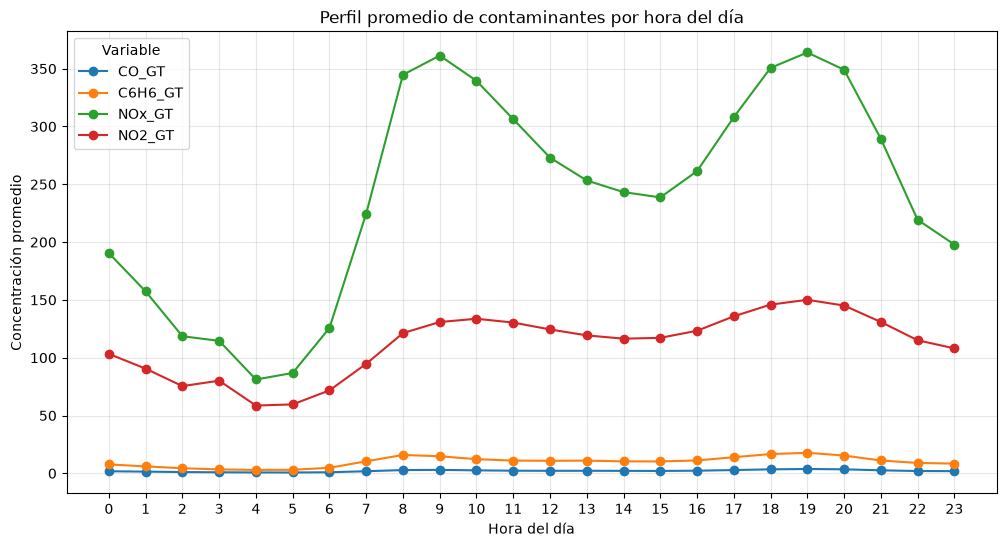

In [14]:
hourly_profile.plot(
    figsize=(12, 6),
    marker="o"
)
plt.title("Perfil promedio de contaminantes por hora del día")
plt.xlabel("Hora del día")
plt.ylabel("Concentración promedio")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.legend(title="Variable")
plt.show()

### 6. Patrón intradía de los contaminantes

El perfil promedio por hora muestra que las concentraciones de los contaminantes no permanecen constantes durante el día.

Se observa un patrón intradía definido:

- Las concentraciones disminuyen durante la madrugada.
- A partir de aproximadamente las 06:00 comienzan a incrementarse.
- Se observa un primer período elevado entre aproximadamente las 08:00 y 10:00.
- Durante las horas centrales del día varias concentraciones disminuyen.
- Se presenta un segundo incremento durante la tarde, especialmente entre aproximadamente las 17:00 y 20:00.
- Después de este período las concentraciones vuelven a disminuir.

El comportamiento aparece simultáneamente en varias de las variables analizadas, aunque cada contaminante utiliza una escala y unidad diferente.

**Decisión:** la hora del día contiene información predictiva potencial y deberá considerarse durante Feature Engineering. Se evaluará la creación de variables temporales derivadas de timestamp, como hora, día de la semana y otras representaciones cíclicas. El patrón observado también confirma que la división de los datos para forecasting deberá preservar la estructura temporal.

In [15]:
df["day_of_week"] = df["timestamp"].dt.dayofweek
day_names = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo",
}
weekly_profile = (
    df.groupby("day_of_week")[["CO_GT", "C6H6_GT", "NOx_GT", "NO2_GT"]]
    .mean()
    .round(2)
)
weekly_profile.index = weekly_profile.index.map(day_names)
weekly_profile

,CO_GT,C6H6_GT,NOx_GT,NO2_GT
day_of_week,,,,
Lunes,2.02,9.96,234.93,110.30
Martes,2.38,11.68,267.67,117.39
Miércoles,2.40,11.40,270.43,120.01
Jueves,2.46,11.53,282.60,120.84
Viernes,2.54,11.73,284.51,123.45
Sábado,1.86,8.51,224.49,107.57
Domingo,1.44,6.05,162.00,91.66


### 7. Patrón semanal de los contaminantes

El análisis por día de la semana muestra diferencias sistemáticas en las concentraciones promedio de los contaminantes.

Los niveles tienden a incrementarse durante los días laborales y disminuir durante el fin de semana.

El viernes presenta los mayores promedios observados:

- CO_GT: **2.54**
- C6H6_GT: **11.73**
- NOx_GT: **284.51**
- NO2_GT: **123.45**

El domingo presenta los menores promedios:

- CO_GT: **1.44**
- C6H6_GT: **6.05**
- NOx_GT: **162.00**
- NO2_GT: **91.66**

Este comportamiento muestra que existe una estructura semanal en los datos. El EDA por sí solo no permite atribuir causalidad a estas diferencias, por lo que no se asumirá que corresponden necesariamente a tráfico, actividad industrial u otra fuente sin evidencia adicional.

**Decisión:** el día de la semana contiene información temporal potencialmente útil para forecasting. Durante Feature Engineering se considerará generar variables derivadas de timestamp que representen el día de la semana y permitan al modelo aprender este patrón recurrente.

In [16]:
df["month"] = df["timestamp"].dt.month
monthly_profile = (
    df.groupby("month")[["CO_GT", "C6H6_GT", "NOx_GT", "NO2_GT"]]
    .mean()
    .round(2)
)
monthly_profile

,CO_GT,C6H6_GT,NOx_GT,NO2_GT
month,,,,
1,2.14,9.02,349.82,134.78
2,2.10,7.50,315.04,160.69
3,2.14,9.22,243.18,123.29
4,2.14,9.71,145.64,98.71
5,1.94,10.22,122.13,93.15
6,1.90,10.60,122.06,94.08
7,1.78,10.60,126.75,104.12
8,1.28,6.99,75.87,70.10
9,2.16,11.55,280.57,108.05


### 8. Patrón mensual y posible estacionalidad

El análisis mensual muestra variaciones importantes en las concentraciones promedio a lo largo del año, lo que proporciona evidencia exploratoria de un posible componente estacional.

Entre los patrones observados destacan:

- NOx_GT presenta valores relativamente bajos entre abril y agosto y aumenta considerablemente entre septiembre y febrero, alcanzando su mayor promedio en noviembre (**424.19**).
- CO_GT presenta su menor promedio en agosto (**1.28**) y valores más elevados entre octubre y diciembre, con un máximo mensual de **2.75** en diciembre.
- C6H6_GT alcanza su mayor promedio en octubre (**13.53**) y su menor promedio en agosto (**6.99**).
- NO2_GT presenta su mayor promedio en febrero (**160.69**) y el menor en agosto (**70.10**).

En conjunto, las variables muestran cambios mensuales que sugieren la existencia de una estructura temporal de mediano plazo.

Sin embargo, estos resultados corresponden a promedios mensuales y no demuestran por sí solos una estacionalidad estadística ni permiten determinar sus causas.

**Decisión:** el mes del año se considerará como una posible característica temporal durante Feature Engineering. Antes del entrenamiento se analizará también la dependencia temporal de la variable objetivo seleccionada para determinar qué patrones y rezagos pueden ser útiles para forecasting.

In [17]:
pollutants = ["CO_GT", "C6H6_GT", "NOx_GT", "NO2_GT"]
lags = [1, 2, 3, 6, 12, 24]
autocorrelation_report = pd.DataFrame({
    col: [df[col].autocorr(lag=lag) for lag in lags]
    for col in pollutants
}, index=lags)
autocorrelation_report.index.name = "lag_horas"
autocorrelation_report.round(3)

,CO_GT,C6H6_GT,NOx_GT,NO2_GT
lag_horas,,,,
1,0.837,0.839,0.903,0.900
2,0.605,0.614,0.768,0.756
3,0.431,0.436,0.644,0.612
6,0.160,0.165,0.453,0.352
12,0.113,0.131,0.366,0.234
24,0.605,0.632,0.675,0.708


### 9. Autocorrelación temporal

Se evaluó la autocorrelación de las principales variables contaminantes utilizando rezagos de 1, 2, 3, 6, 12 y 24 horas.
Los resultados muestran una fuerte dependencia temporal a corto plazo.
A una hora de rezago se obtuvieron:

- CO_GT: **0.837**
- C6H6_GT: **0.839**
- NOx_GT: **0.903**
- NO2_GT: **0.900**

La autocorrelación disminuye progresivamente conforme aumenta el rezago. Sin embargo, a las **24 horas vuelve a observarse una relación considerable**:

- CO_GT: **0.605**
- C6H6_GT: **0.632**
- NOx_GT: **0.675**
- NO2_GT: **0.708**

Este comportamiento es consistente con el patrón intradía observado anteriormente y proporciona evidencia de una estructura temporal diaria en las concentraciones.

**Decisión:** los valores históricos contienen información predictiva importante. Durante Feature Engineering se considerará crear variables de rezago (lags), especialmente de corto plazo y de **24 horas**, para que los modelos puedan aprovechar tanto la persistencia reciente como los patrones diarios.

La selección definitiva de los rezagos se realizará después de elegir la variable ambiental objetivo, evitando utilizar información futura que pueda producir *data leakage*.

In [ ]:

continuity_report = []
for col in ["CO_GT", "C6H6_GT", "NOx_GT", "NO2_GT"]:
    serie = df.set_index("timestamp")[col]
    validos = serie.notna()
    cambios = validos.ne(validos.shift()).cumsum()
    bloques_nan = (
        serie[~validos]
        .groupby(cambios[~validos])
        .size()
    )
    continuity_report.append({
        "variable": col,
        "valores_validos": validos.sum(),
        "faltantes": (~validos).sum(),
        "bloques_faltantes": len(bloques_nan),
        "mayor_bloque_horas": bloques_nan.max() if len(bloques_nan) else 0
    })
continuity_report = pd.DataFrame(continuity_report)
continuity_report